In [ ]:
import os
from google.colab import drive

# Define the target mount point
mount_dir = '/content/drive'

# Check if the Drive directory is already mounted and accessible
if os.path.exists(os.path.join(mount_dir, 'MyDrive')):

    print("Google Drive is already mounted.")
else:
    print("Google Drive not mounted. Mounting now...")
    drive.mount(mount_dir)

Google Drive not mounted. Mounting now...
Mounted at /content/drive


# Optimized Taxi Fare Prediction Model

In [ ]:
import os
import gc
import pickle

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score
)

## 1. Configuration

Define constants for data path, random state, and memory management parameters like `CHUNK_SIZE` and `LARGE_DATA_THRESHOLD`. Option to use sampling is also configured here.

In [ ]:
DATA_PATH = (
    "/content/drive/MyDrive/DATATHON/Telementors/Fare/train_scaled_rolling.csv"
)

RANDOM_STATE = 42

# RAM condition for chunk processing
# Low RAM       -> 250,000
# Normal Colab  -> 500,000
# High RAM      -> 1,000,000
CHUNK_SIZE = 500_000

# Large data condition threshold
LARGE_DATA_THRESHOLD = 2_000_000

# Optional sampling for very large datasets
SAMPLE_FRAC = 0.05
USE_SAMPLING = False

## 2. Identify Available Columns

This step reads only the header of the CSV file to identify all available columns without loading the entire dataset into memory.

In [ ]:
# ============================================================
# RESTORE CORRECT COLUMN NAMES
# ============================================================

correct_columns = [
    "provider_code",
    "pickup_timestamp",
    "dropoff_timestamp",
    "rider_count",
    "distance_miles",
    "rate_class_id",
    "offline_record_flag",
    "origin_loc_id",
    "dest_loc_id",
    "fare_settlement_method",
    "base_fare",
    "surcharge_misc",
    "transit_tax",
    "driver_tip_payment",
    "toll_total",
    "service_improvement_fee",
    "charge_total",
    "zone_congestion_fee",
    "Airport_fee",
    "congestion_relief_fee"
]


# ============================================================
# READ COLUMN STRUCTURE USING CORRECT NAMES
# ============================================================

cols_available = pd.read_csv(
    DATA_PATH,
    nrows=0,
    names=correct_columns,
    header=0
).columns.tolist()

print("Available columns:")
print(cols_available)

Available columns:
['provider_code', 'pickup_timestamp', 'dropoff_timestamp', 'rider_count', 'distance_miles', 'rate_class_id', 'offline_record_flag', 'origin_loc_id', 'dest_loc_id', 'fare_settlement_method', 'base_fare', 'surcharge_misc', 'transit_tax', 'driver_tip_payment', 'toll_total', 'service_improvement_fee', 'charge_total', 'zone_congestion_fee', 'Airport_fee', 'congestion_relief_fee']


## 3. Column Candidates and Selection Logic

Define candidate column names for key features (e.g., `pickup_timestamp`, `distance_miles`, `fare_amount`). A helper function `first_present` is used to find the first existing column from a list of candidates in the dataset.

In [ ]:
pickup_candidates = [
    'pickup_timestamp',
    'tpep_pickup_datetime',
    'pickup_datetime'
]

dropoff_candidates = [
    'dropoff_timestamp',
    'tpep_dropoff_datetime',
    'dropoff_datetime'
]

distance_candidates = [
    'distance_miles',
    'trip_distance'
]

fare_candidates = [
    'base_fare',
    'fare_amount'
]

rider_candidates = [
    'rider_count',
    'passenger_count'
]

rate_candidates = [
    'rate_class_id',
    'RatecodeID'
]

origin_candidates = [
    'origin_loc_id',
    'PULocationID'
]

destination_candidates = [
    'dest_loc_id',
    'DOLocationID'
]

def first_present(candidates):
    for col in candidates:
        if col in cols_available:
            return col
    return None

In [ ]:
pickup_col = first_present(pickup_candidates)
dropoff_col = first_present(dropoff_candidates)
distance_col = first_present(distance_candidates)
fare_col = first_present(fare_candidates)
rider_col = first_present(rider_candidates)
rate_col = first_present(rate_candidates)
origin_col = first_present(origin_candidates)
destination_col = first_present(destination_candidates)

print("\nDetected columns")
print("----------------------------")
print(f"Target fare    : {fare_col}")
print(f"Distance       : {distance_col}")
print(f"Pickup time    : {pickup_col}")
print(f"Dropoff time   : {dropoff_col}")
print(f"Rider count    : {rider_col}")
print(f"Rate class     : {rate_col}")
print(f"Origin zone    : {origin_col}")
print(f"Destination    : {destination_col}")


Detected columns
----------------------------
Target fare    : base_fare
Distance       : distance_miles
Pickup time    : pickup_timestamp
Dropoff time   : dropoff_timestamp
Rider count    : rider_count
Rate class     : rate_class_id
Origin zone    : origin_loc_id
Destination    : dest_loc_id


## 4. Required Column Validation & `use_cols` Construction

Ensure that essential columns like `fare_col` and `distance_col` are present. Construct the final list of columns to be loaded from the dataset, including optional columns if they exist.

In [ ]:
if fare_col is None:
    raise ValueError("❌ Fare target column not found.")

if distance_col is None:
    raise ValueError("❌ Distance column not found.")

use_cols = [
    fare_col,
    distance_col
]

optional_cols = [
    pickup_col,
    dropoff_col,
    rider_col,
    rate_col,
    origin_col,
    destination_col
]

for col in optional_cols:
    if (col is not None and col not in use_cols):
        use_cols.append(col)

print("\nColumns that will actually be loaded:")
print(use_cols)


Columns that will actually be loaded:
['base_fare', 'distance_miles', 'pickup_timestamp', 'dropoff_timestamp', 'rider_count', 'rate_class_id', 'origin_loc_id', 'dest_loc_id']


## 5. Count Total Rows (Memory-Safe)

Determine the total number of rows in the dataset without loading it entirely into memory, which helps in deciding whether to use chunk-based processing.

In [ ]:
print("\nChecking dataset size...")

total_rows = 0

for temp_chunk in pd.read_csv(
    DATA_PATH,

    names=correct_columns,   # use corrected column names
    header=0,                # ignore wrong first-row header

    usecols=[fare_col],

    chunksize=1_000_000
):

    total_rows += len(temp_chunk)

    del temp_chunk

    gc.collect()


print(f"Total rows: {total_rows:,}")


if total_rows > LARGE_DATA_THRESHOLD:

    print("\n⚠️ Large dataset detected.")
    print("Using chunk-based processing to protect Colab RAM.")

else:

    print("\nDataset is below 2,000,000 rows.")


Checking dataset size...
Total rows: 12,253,804

⚠️ Large dataset detected.
Using chunk-based processing to protect Colab RAM.


## 6. Chunked Data Processing

This section processes the dataset in chunks to manage memory efficiently. For each chunk, it performs:

1.  **Optional Sampling**: If `USE_SAMPLING` is enabled for large datasets.
2.  **Type Conversion**: Converts numeric and datetime columns to appropriate types.
3.  **Data Cleaning**: Drops rows with invalid fare or distance values and filters for positive fare and distance.
4.  **Feature Engineering**: Creates `trip_duration_minutes`, `pickup_hour`, `day_of_week`, and `is_weekend` features.
5.  **RAM Reduction**: Downcasts numeric types to smaller memory footprints.

Finally, all processed chunks are combined into a single `fare_df` DataFrame.

In [ ]:
processed_chunks = []
processed_rows = 0
chunk_number = 0

print("\nStarting memory-safe fare preprocessing...")

reader = pd.read_csv(
    DATA_PATH,
    names=correct_columns,   # restore correct names
    header=0,                # skip corrupted header row
    usecols=use_cols,
    chunksize=CHUNK_SIZE
)

for chunk in reader:
    chunk_number += 1
    processed_rows += len(chunk)

    # Optional sampling condition
    if (USE_SAMPLING and total_rows > LARGE_DATA_THRESHOLD):
        chunk = chunk.sample(
            frac=SAMPLE_FRAC,
            random_state=(RANDOM_STATE + chunk_number)
        )

    # Numeric conversion
    numeric_candidates = [
        fare_col,
        distance_col,
        rider_col,
        rate_col,
        origin_col,
        destination_col
    ]

    for col in numeric_candidates:
        if col is not None and col in chunk.columns:
            chunk[col] = pd.to_numeric(
                chunk[col],
                errors='coerce'
            )

    # Datetime conversion
    if pickup_col is not None:
        chunk[pickup_col] = pd.to_datetime(
            chunk[pickup_col],
            errors='coerce'
        )

    if dropoff_col is not None:
        chunk[dropoff_col] = pd.to_datetime(
            chunk[dropoff_col],
            errors='coerce'
        )

    # Drop invalid target/distance
    chunk.dropna(
        subset=[fare_col, distance_col],
        inplace=True
    )

    chunk = chunk[chunk[fare_col] > 0]
    chunk = chunk[chunk[distance_col] > 0]

    # Create trip duration
    if pickup_col is not None and dropoff_col is not None:

        chunk['trip_duration_minutes'] = (
            (
                chunk[dropoff_col]
                - chunk[pickup_col]
            ).dt.total_seconds()
            / 60.0
        )

        chunk.loc[
            chunk['trip_duration_minutes'] <= 0,
            'trip_duration_minutes'
        ] = np.nan

    # Create time features
    if pickup_col is not None:

        chunk['pickup_hour'] = chunk[pickup_col].dt.hour
        chunk['day_of_week'] = chunk[pickup_col].dt.dayofweek

        chunk['is_weekend'] = (
            chunk['day_of_week']
            .isin([5, 6])
            .astype('int8')
        )

    # Drop original timestamp columns
    timestamp_cols_to_drop = [
        col
        for col in [pickup_col, dropoff_col]
        if col is not None and col in chunk.columns
    ]

    chunk.drop(
        columns=timestamp_cols_to_drop,
        inplace=True
    )

    # Reduce RAM
    for col in chunk.columns:

        if pd.api.types.is_float_dtype(chunk[col]):

            chunk[col] = pd.to_numeric(
                chunk[col],
                downcast='float'
            )

        elif pd.api.types.is_integer_dtype(chunk[col]):

            chunk[col] = pd.to_numeric(
                chunk[col],
                downcast='integer'
            )

    processed_chunks.append(chunk)

    print(
        f"Chunk {chunk_number:02d} | "
        f"Processed: {processed_rows:,} / {total_rows:,} | "
        f"Kept: {len(chunk):,}"
    )

    del chunk
    gc.collect()


Starting memory-safe fare preprocessing...
Chunk 01 | Processed: 500,000 / 12,253,804 | Kept: 193,424
Chunk 02 | Processed: 1,000,000 / 12,253,804 | Kept: 197,290
Chunk 03 | Processed: 1,500,000 / 12,253,804 | Kept: 193,092
Chunk 04 | Processed: 2,000,000 / 12,253,804 | Kept: 194,022
Chunk 05 | Processed: 2,500,000 / 12,253,804 | Kept: 206,429
Chunk 06 | Processed: 3,000,000 / 12,253,804 | Kept: 235,342
Chunk 07 | Processed: 3,500,000 / 12,253,804 | Kept: 174,377
Chunk 08 | Processed: 4,000,000 / 12,253,804 | Kept: 211,941
Chunk 09 | Processed: 4,500,000 / 12,253,804 | Kept: 194,867
Chunk 10 | Processed: 5,000,000 / 12,253,804 | Kept: 194,859
Chunk 11 | Processed: 5,500,000 / 12,253,804 | Kept: 196,656
Chunk 12 | Processed: 6,000,000 / 12,253,804 | Kept: 198,005
Chunk 13 | Processed: 6,500,000 / 12,253,804 | Kept: 193,299
Chunk 14 | Processed: 7,000,000 / 12,253,804 | Kept: 223,497
Chunk 15 | Processed: 7,500,000 / 12,253,804 | Kept: 241,643
Chunk 16 | Processed: 8,000,000 / 12,253,80

## 7. Combine Processed Chunks

Concatenate all processed data chunks into a single DataFrame `fare_df`.

In [ ]:
print("\nCombining processed chunks...")

fare_df = pd.concat(
    processed_chunks,
    ignore_index=True
)

del processed_chunks
gc.collect()

print(
    f"✅ Fare dataset: "
    f"{fare_df.shape[0]:,} rows × "
    f"{fare_df.shape[1]} columns"
)


Combining processed chunks...
✅ Fare dataset: 4,921,845 rows × 10 columns


## 8. Build Feature and Target Sets

Define the features (`X`) and the target variable (`y`) for the model. Missing values in features are imputed using their median.

In [ ]:
feature_candidates = [
    distance_col,
    'trip_duration_minutes',
    rider_col,
    rate_col,
    origin_col,
    destination_col,
    'pickup_hour',
    'day_of_week',
    'is_weekend'
]

feature_cols = [
    col for col in feature_candidates
    if (col is not None and col in fare_df.columns)
]

print("\nFeatures used:")
for feature in feature_cols:
    print("-", feature)

print("\nTarget:", fare_col)

X = fare_df[feature_cols].copy()
y = fare_df[fare_col].astype('float32')

# Handle missing values in features by imputing with the median
for col in feature_cols:
    if X[col].isna().any():
        median_value = X[col].median()
        X[col] = X[col].fillna(median_value)

# Reduce RAM for model training
X = X.astype('float32')
gc.collect()


Features used:
- distance_miles
- trip_duration_minutes
- rider_count
- rate_class_id
- origin_loc_id
- dest_loc_id
- pickup_hour
- day_of_week
- is_weekend

Target: base_fare


0

## 9. Train / Test Split

Split the data into training and testing sets to evaluate the model's performance on unseen data.

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=RANDOM_STATE
)

del X
del y
gc.collect()

print(f"\nTraining rows: {len(X_train):,}")
print(f"Testing rows : {len(X_test):,}")


Training rows: 3,937,476
Testing rows : 984,369


## 10. Train Linear Regression Model

Initialize and train a `LinearRegression` model using the training data.

In [ ]:
print("\nTraining Linear Regression model...")

model = LinearRegression()
model.fit(
    X_train,
    y_train
)

print("✅ Model training complete.")


Training Linear Regression model...
✅ Model training complete.


## 11. Predict and Evaluate Metrics

Make predictions on the test set and calculate key regression metrics: RMSE, MAE, and R².

In [ ]:
pred = model.predict(X_test)
pred = np.maximum(pred, 0) # Fare cannot logically be negative

rmse = float(np.sqrt(mean_squared_error(y_test, pred)))
mae = float(mean_absolute_error(y_test, pred))
r2 = float(r2_score(y_test, pred))

print("\n======================================")
print("Fare Prediction Model [Linear Regression]")
print("======================================")
print(f"RMSE: {rmse:.2f} | MAE: {mae:.2f} | R²: {r2:.4f}")
print("Features used:", feature_cols)


Fare Prediction Model [Linear Regression]
RMSE: 22.24 | MAE: 0.99 | R²: -0.0000
Features used: ['distance_miles', 'trip_duration_minutes', 'rider_count', 'rate_class_id', 'origin_loc_id', 'dest_loc_id', 'pickup_hour', 'day_of_week', 'is_weekend']


## 12. Analyze Coefficients

Display the coefficients of the linear regression model, sorted by their absolute values to understand feature importance.

In [ ]:
coefficients = pd.DataFrame({
    'Feature': feature_cols,
    'Coefficient': model.coef_
})

coefficients['Absolute_Coefficient'] = coefficients['Coefficient'].abs()
coefficients = coefficients.sort_values(
    'Absolute_Coefficient',
    ascending=False
)

print("\nLinear Regression coefficients:")
display(coefficients)


Linear Regression coefficients:


,Feature,Coefficient,Absolute_Coefficient
0,distance_miles,3.062560e-05,3.062560e-05
1,trip_duration_minutes,9.122068e-09,9.122068e-09
6,pickup_hour,-1.836925e-09,1.836925e-09
4,origin_loc_id,-3.649306e-10,3.649306e-10
5,dest_loc_id,-1.002437e-10,1.002437e-10
7,day_of_week,-2.643771e-11,2.643771e-11
2,rider_count,-1.230332e-11,1.230332e-11
3,rate_class_id,-1.004756e-11,1.004756e-11
8,is_weekend,2.539154e-12,2.539154e-12


## 13. Visualize Actual vs. Predicted Fares

Create a scatter plot comparing actual fare values against predicted fare values for a sample of the test set, including a reference line for perfect predictions.

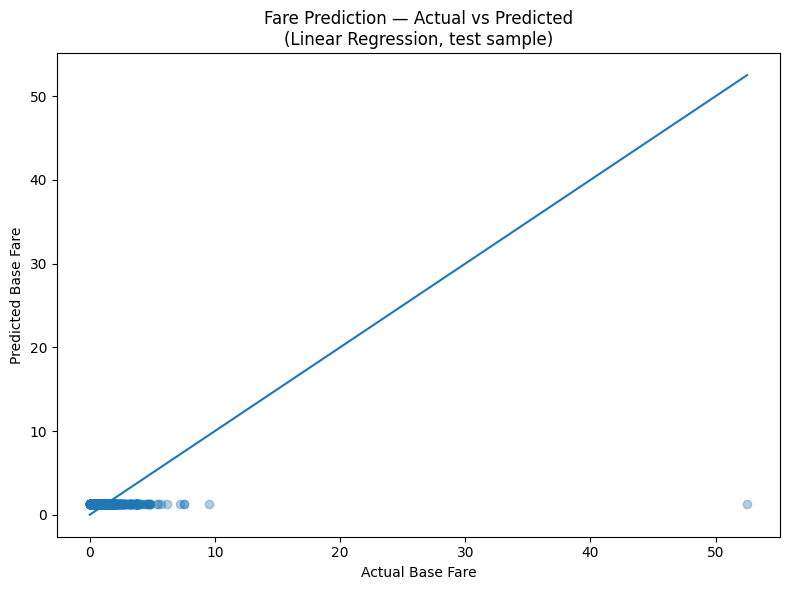

In [ ]:
plt.figure(figsize=(8, 6))

rng = np.random.RandomState(RANDOM_STATE)
idx = rng.choice(
    len(y_test),
    size=min(800, len(y_test)),
    replace=False
)

actual_sample = y_test.iloc[idx].to_numpy()
pred_sample = np.asarray(pred)[idx]

plt.scatter(
    actual_sample,
    pred_sample,
    alpha=0.35
)

lims = [
    min(actual_sample.min(), pred_sample.min()),
    max(actual_sample.max(), pred_sample.max())
]

plt.plot(lims, lims)
plt.xlabel("Actual Base Fare")
plt.ylabel("Predicted Base Fare")
plt.title(
    "Fare Prediction — Actual vs Predicted\n"
    "(Linear Regression, test sample)"
)
plt.tight_layout()
plt.show()

## 14. Residual Plot Analysis

Generate a residual plot to visualize the distribution of prediction errors. This helps in identifying patterns in the residuals, which could indicate model biases or unmet assumptions.

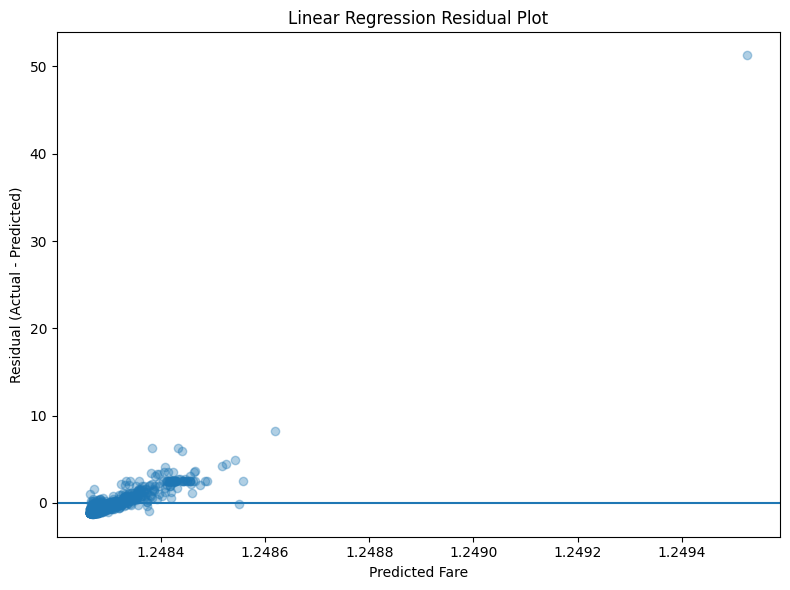

In [ ]:
residual_sample = actual_sample - pred_sample

plt.figure(figsize=(8, 6))

plt.scatter(
    pred_sample,
    residual_sample,
    alpha=0.35
)

plt.axhline(y=0)
plt.xlabel("Predicted Fare")
plt.ylabel("Residual (Actual - Predicted)")
plt.title("Linear Regression Residual Plot")
plt.tight_layout()
plt.show()

## 15. Save Prediction Data

Save the actual and predicted fare values from the test set to a CSV file. This allows for external analysis or further use of the predictions.

In [ ]:
output_folder = "/content/drive/MyDrive/DATATHON/Fare_PREDICTION"

if not os.path.exists(output_folder):
    os.makedirs(output_folder)
    print(f"📁 Folder created: {output_folder}")
else:
    print(f"📁 Folder already exists: {output_folder}")

prediction_path = os.path.join(
    output_folder,
    "fare_prediction_results.csv"
)

prediction_df = pd.DataFrame({
    'actual_fare': y_test.to_numpy(),
    'predicted_fare': pred
})

prediction_df.to_csv(
    prediction_path,
    index=False
)

print(f"💾 Predictions saved: {prediction_path}")

📁 Folder already exists: /content/drive/MyDrive/DATATHON/Fare_PREDICTION
💾 Predictions saved: /content/drive/MyDrive/DATATHON/Fare_PREDICTION/fare_prediction_results.csv


## 16. Save Trained Model

Serialize and save the trained `LinearRegression` model using `pickle`. This allows the model to be loaded and reused later without retraining.

In [ ]:
model_folder = "/content/drive/MyDrive/DATATHON/MODEL"

if not os.path.exists(model_folder):
    os.makedirs(model_folder)
    print(f"📁 Folder created: {model_folder}")
else:
    print(f"📁 Folder already exists: {model_folder}")

model_path = os.path.join(
    model_folder,
    "linear_regression_fare_model.pkl"
)

with open(
    model_path,
    "wb"
) as file:
    pickle.dump(model, file)

print(f"💾 Model saved: {model_path}")

📁 Folder created: /content/drive/MyDrive/DATATHON/MODEL
💾 Model saved: /content/drive/MyDrive/DATATHON/MODEL/linear_regression_fare_model.pkl


## 17. Addressing Poor Linear Regression Performance: Exploring Non-Linear Models

The extremely low R-squared value (close to zero or negative) and the absence of a discernible pattern in the residual plot indicate that a simple linear regression model is not suitable for capturing the underlying relationships in this dataset. This suggests that the relationship between features and the target variable (`base_fare`) is likely non-linear.

Since the data is already scaled, we will now explore a more robust, non-linear model: the **Random Forest Regressor**. Random Forest models are ensemble methods that can capture complex, non-linear patterns and interactions between features without requiring extensive manual feature engineering for non-linearity.

In [24]:
from sklearn.ensemble import RandomForestRegressor

print("\nTraining Random Forest Regressor model...")

# Initialize and train the Random Forest Regressor
# n_estimators: number of trees in the forest
# random_state: for reproducibility
# n_jobs=-1: use all available processors
# max_depth, min_samples_leaf can be tuned further
rf_model = RandomForestRegressor(n_estimators=100, random_state=RANDOM_STATE, n_jobs=-1)

rf_model.fit(
    X_train,
    y_train
)

print("✅ Random Forest model training complete.")


Training Random Forest Regressor model...


KeyboardInterrupt: 

### 17.1 Evaluate Random Forest Model

Now, let's evaluate the Random Forest Regressor using the same metrics.

In [ ]:
rf_pred = rf_model.predict(X_test)
rf_pred = np.maximum(rf_pred, 0) # Fare cannot logically be negative

rf_rmse = float(np.sqrt(mean_squared_error(y_test, rf_pred)))
rf_mae = float(mean_absolute_error(y_test, rf_pred))
rf_r2 = float(r2_score(y_test, rf_pred))

print("\n==========================================")
print("Fare Prediction Model [Random Forest Regressor]")
print("==========================================")
print(f"RMSE: {rf_rmse:.2f} | MAE: {rf_mae:.2f} | R²: {rf_r2:.4f}")
print("Features used:", feature_cols)

### 17.2 Visualize Actual vs. Predicted Fares (Random Forest)

Let's re-plot the actual vs. predicted fares for the Random Forest model.

In [ ]:
plt.figure(figsize=(8, 6))

plt.scatter(
    actual_sample,
    rf_pred[idx], # Using rf_pred for Random Forest
    alpha=0.35
)

plt.plot(lims, lims)
plt.xlabel("Actual Base Fare")
plt.ylabel("Predicted Base Fare")
plt.title(
    "Fare Prediction — Actual vs Predicted\n"
    "(Random Forest Regressor, test sample)"
)
plt.tight_layout()
plt.show()

### 17.3 Residual Plot Analysis (Random Forest)

Finally, let's look at the residual plot for the Random Forest model.

In [ ]:
rf_residual_sample = actual_sample - rf_pred[idx]

plt.figure(figsize=(8, 6))

plt.scatter(
    rf_pred[idx],
    rf_residual_sample,
    alpha=0.35
)

plt.axhline(y=0)
plt.xlabel("Predicted Fare")
plt.ylabel("Residual (Actual - Predicted)")
plt.title("Random Forest Regressor Residual Plot")
plt.tight_layout()
plt.show()

In [25]:
!git remo

!git add notebooks/fare_prediction_model




fatal: not a git repository (or any of the parent directories): .git


### 17.4 Summary and Next Steps

Compare the metrics and plots from the Linear Regression model and the Random Forest Regressor. The Random Forest model should show a significantly improved R-squared value and potentially a more uniform spread of residuals around zero, indicating a better fit.

**Next Steps for further improvement:**
*   **Hyperparameter Tuning**: Optimize `n_estimators`, `max_depth`, `min_samples_leaf`, etc., for the Random Forest model.
*   **Feature Importance**: Analyze feature importance from the Random Forest model to understand which features contribute most to predictions.
*   **Cross-Validation**: Use cross-validation for more robust model evaluation.
*   **Other Ensemble Models**: Experiment with Gradient Boosting models (e.g., XGBoost, LightGBM) for potentially even better performance.